<a href="https://colab.research.google.com/github/MrJunVN/MrJunVN/blob/main/Task2Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student IDs: XXXXXXX, XXXXXXX, XXXXXX <br>
Student Names: xxxxxxx, xxxxxxx, xxxxxxx <br>
Group Number: 64 <br>
Workshop/Lab Session Time: Tuesday 5-7pm <br>

# **Part 1**

## Setting up Spark
In this section we:

*   Download a specific version of spark and set environment vairables so that this is the version that is used.
*   Install and use findspark
*   Import and create a SparkSession


In [1]:
# Install wget
!pip install wget

# Import wget so we can use from Python
import wget

##### This code is required for own spark version #####
# Update local version of the package catalog
#!apt-get update

# Install Java8
#!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Download spark 3.5.6
#!wget -q https://archive.apache.org/dist/spark/spark-3.5.6/spark-3.5.6-bin-hadoop3.tgz

# unzip it
#!tar xf spark-3.5.6-bin-hadoop3.tgz

#import os
#os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
#os.environ["SPARK_HOME"] = "/content/spark-3.5.6-bin-hadoop3"
###### OWN SPARK VERSION #####

# Install findspark
!pip install -q findspark

import findspark
findspark.init()

from pyspark.sql import SparkSession

# Create a SparkSession
spark = SparkSession.builder.appName("SIT742-A2-P1").getOrCreate()

# Get the SparkContext.
#sc = spark.SparkContext # MIGHT NOT NEED BUT HERE IF REQUIRED



  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=0dd0313e4047861f2794c4101c752e08aaca058bfed4d21f6939edd07fe4ca96
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [2]:
# Print information about spark
spark

# Download and load data required for Part 1
This section creates a data directory, downloads the data files for part 1 from the SIT742 GitHub repositroy and extracts them into the data directory. Lastly the zip file is removed.

In [3]:
# Create data directory
!mkdir -p data

# Download the data for part 1 from the the GitHub repository
!wget -q https://github.com/tulip-lab/sit742/raw/develop/Jupyter/data/business_review_submission.zip

# Unzip the folder int othe data directory
!unzip business_review_submission.zip -d data

# Remove the zip file
!rm business_review_submission.zip


Archive:  business_review_submission.zip
  inflating: data/review.csv         
  inflating: data/meta-review-business.csv  


In [4]:
# Load the data into a DataFrame
data_file_path = "./data/review.csv"
sdf = spark.read.csv(data_file_path, header=True, inferSchema=True)

In [5]:
# Display schema of DataFrame
sdf.printSchema()

# Show the initial DataFrame
print("Initial DataFrame:")
sdf.show(10)

root
 |-- user_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- time: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- text: string (nullable = true)
 |-- pics: string (nullable = true)
 |-- resp: string (nullable = true)
 |-- gmap_id: string (nullable = true)

Initial DataFrame:
+--------------------+--------------------+-------------+--------------------+--------------------+--------------------+----+--------------------+
|             user_id|                name|         time|              rating|                text|                pics|resp|             gmap_id|
+--------------------+--------------------+-------------+--------------------+--------------------+--------------------+----+--------------------+
|1.091298048426862...|          Nicki Gore|1566331951619|                   5|We always stay he...|                NULL|NULL|0x56b646ed2220b77...|
|1.132409264057589...|       Allen Ratliff|1504917982385|                   5|Great campgro

## Answer 1.1

In [6]:
""" 1.1.1
Repalce none/null in text column with "no review".
"""
from pyspark.sql.functions import col, count

# Count nulls for "text" column
text_null_counts = sdf.filter(col("text").isNull()).count()

# Display the counts
print(f'Null count in "text" column: {text_null_counts}')

# Replace none/NULL with "no review" in "text" column
sdf_filled = sdf.fillna("no review", subset=["text"])

# Count nulls for "text" column after replacement
null_count = sdf_filled.filter(col("text").isNull()).count()
print(f'Null count in "text" column after replacement: {null_count}')

#### Answers for report
# Why:
# Alternatives:
# 1. Using withColumn() and when().
# 2. Using Spark SQL.
# Optimal: The approach chosen is the most optimal. It avoids evaluating
# expressions.

Null count in "text" column: 249931
Null count in "text" column after replacement: 0


In [7]:
""" 1.1.2
Process the content in time column, and convert the strings from time to
yyyy-mm-dd format in the new column as newtime and show the first 5 rows.
"""

from pyspark.sql.functions import col, when, from_unixtime, regexp_extract, length, date_format

# Here we convert the time column into a string yyy-mm-dd format
# The time appeas to be a unix timetamp in milliseconds which will be 13 digits.
# I have assumed we are require to retun a string not a DateType
# For a DateType use this code instead:
# to_date(from_unixtime(col("time") / 1000))
#
sdf_with_date = sdf_filled.withColumn(
    "newtime", # new column name
    when(
        col("time").rlike("^[0-9]+$") &
        (length(col("time")) == 13),   # 13 digits for a unix timestamp in milliseconds
        date_format(from_unixtime(col("time") / 1000), "yyyy-MM-dd") # This creates a string column in yyyy-MM-dd format
        ).otherwise(None) # all others return Null
)

# Show the first five rows
sdf_with_date.show(5)

#### Answers for report
# Why:
# Alternatives:
# 1. Using expr() with inline SQL expressions in withColumn()
# 2. Using a user defined function (UDF) in withColumn()
# Optimal: Chosen approach is optimal as it uses native Spark functions and avoid any Python overhead.

+--------------------+--------------------+-------------+--------------------+--------------------+----+----+--------------------+----------+
|             user_id|                name|         time|              rating|                text|pics|resp|             gmap_id|   newtime|
+--------------------+--------------------+-------------+--------------------+--------------------+----+----+--------------------+----------+
|1.091298048426862...|          Nicki Gore|1566331951619|                   5|We always stay he...|NULL|NULL|0x56b646ed2220b77...|2019-08-20|
|1.132409264057589...|       Allen Ratliff|1504917982385|                   5|Great campground ...|NULL|NULL|0x56b646ed2220b77...|2017-09-09|
|1.130448378911412...|   Jonathan Tringali|1474765901185|                   4|We tent camped he...|NULL|NULL|                NULL|2016-09-25|
|There is a bath h...| 2 restrooms (sin...|       toilet| shower). The hot...| but they lack ve...|NULL|NULL|                NULL|      NULL|
|Wi-Fi


## Answer 1.2

In [8]:
""" 1.2.1
Using pyspark to calculate the number of reviews per each unique gmap_id and save as float
format in pyspark dataframe to show the top 5 rows.
"""

from pyspark.sql.types import FloatType

# Use groupby to get unique gmap_id, then count the reviews for each group, sort.
review_counts = sdf_with_date.groupby(["gmap_id"]).count()\
.withColumn("count", col("count").cast(FloatType())) \
.sort("count", ascending=False)

# Show the top 5 reviewers
review_counts.show(5)

#### Answers for report
# Why:
# Alternatives:
# 1. Using .agg() with count() on the groupby
# Optimal: Chosen method is more optimal as it doesn't have the overhead of an aggregation step.

+--------------------+-------+
|             gmap_id|  count|
+--------------------+-------+
|                NULL|46309.0|
|0x56c897b9ce6000d...| 2737.0|
|0x56c899d05892048...| 2555.0|
|0x56c897c63697ee3...| 2220.0|
|0x56c8965ee2fb87a...| 2202.0|
+--------------------+-------+
only showing top 5 rows



**should we remove the reviews that have a NULL gmap_id?**

In [9]:
# This is an aside. not require for assignment
# Number of uniquie gmap_id's
num_groups = sdf_with_date.select("gmap_id").distinct().count()
print(num_groups)

12468


In [10]:
""" 1.2.2
Transform the current pyspark dataframe to pandas dataframe (named as df)
and create the column reivew_time with the information of review time on hours
level. Print your df pandas dataframe with top 5 rows after creating the column
review_time.
"""

from pyspark.sql.functions import col
import pandas as pd

#REMOVE THIS
print(sdf_with_date.count())

# Use the newdate column to drop invalid time values
sdf_cleaned = sdf_with_date.na.drop(subset=["newtime"])

#REMOVE THIS
print(sdf_cleaned.count())

# Convert the current pyspark dataframe to pandas
df = sdf_cleaned.toPandas()
df.memory_usage(deep=True).sum() / (1024 ** 2)  # in MB

# Create a DateTime coumn as it will be useful later
# time column is unixtime in milliseconds
df["date_time"] = pd.to_datetime(df["time"].astype(int), unit="ms")

# dt.hour sets the time in hours
df["review_time"] = df["date_time"].dt.hour

# Show the top 5 rows of the pandas dataframe
df.head(5)

#### Answers for report
# Why:
# Alternatives:
# 1. datetime.ftomtimestamp() inside an .apply()
# Optimal: Chosen method is optimal as it works on columns not rows like .apply().

552624
521515


,user_id,name,time,rating,text,pics,resp,gmap_id,newtime,date_time,review_time
0,1.091298048426862e+20,Nicki Gore,1566331951619,5,We always stay here when in Valdez for silver ...,None,None,0x56b646ed2220b77f:0xd8975e316de80952,2019-08-20,2019-08-20 20:12:31.619,20
1,1.1324092640575896e+20,Allen Ratliff,1504917982385,5,Great campground for the price. Nice hot unlim...,None,None,0x56b646ed2220b77f:0xd8975e316de80952,2017-09-09,2017-09-09 00:46:22.385,0
2,1.1304483789114126e+20,Jonathan Tringali,1474765901185,4,We tent camped here for 2 nights while explori...,None,None,None,2016-09-25,2016-09-25 01:11:41.185,1
3,1.1032915514759202e+20,S Blad,1472858535682,4,"This place is just a few miles outside Valdez,...",None,None,0x56b646ed2220b77f:0xd8975e316de80952,2016-09-02,2016-09-02 23:22:15.682,23
4,1.08989634908602e+20,Daniel Formoso,1529649811341,5,Probably the nicest and cleanest campground we...,None,None,0x56b646ed2220b77f:0xd8975e316de80952,2018-06-22,2018-06-22 06:43:31.341,6


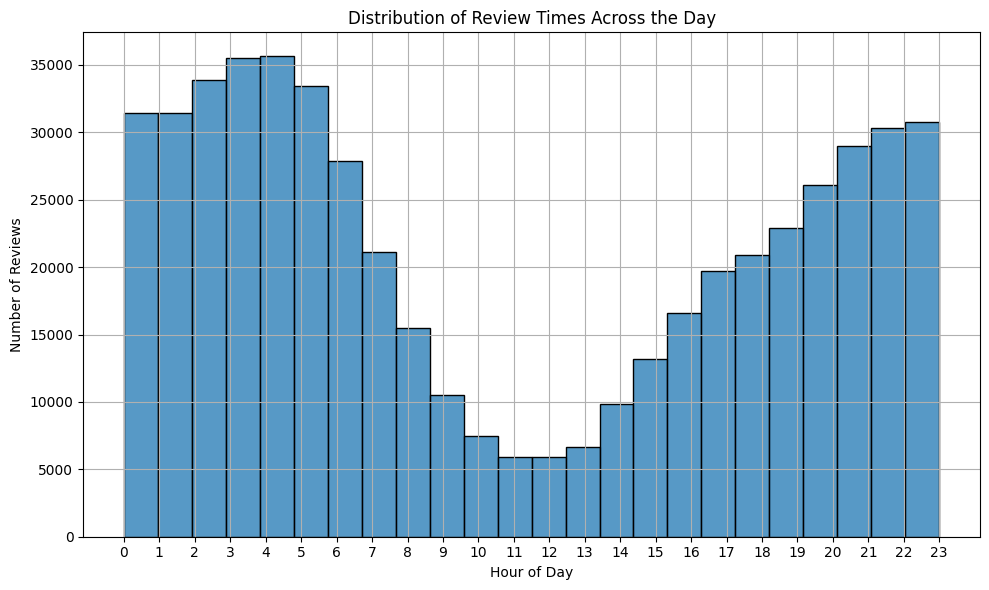

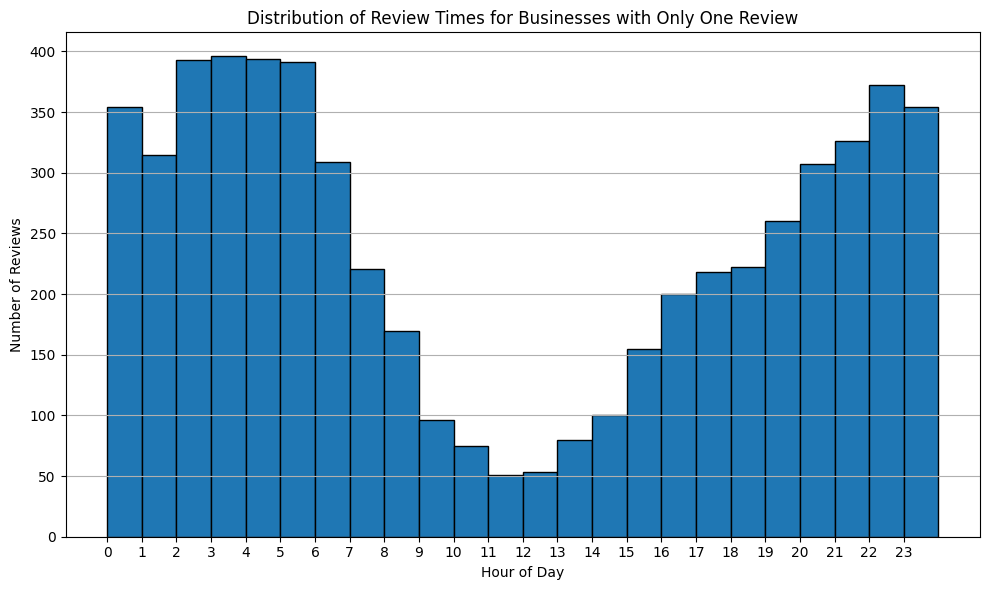

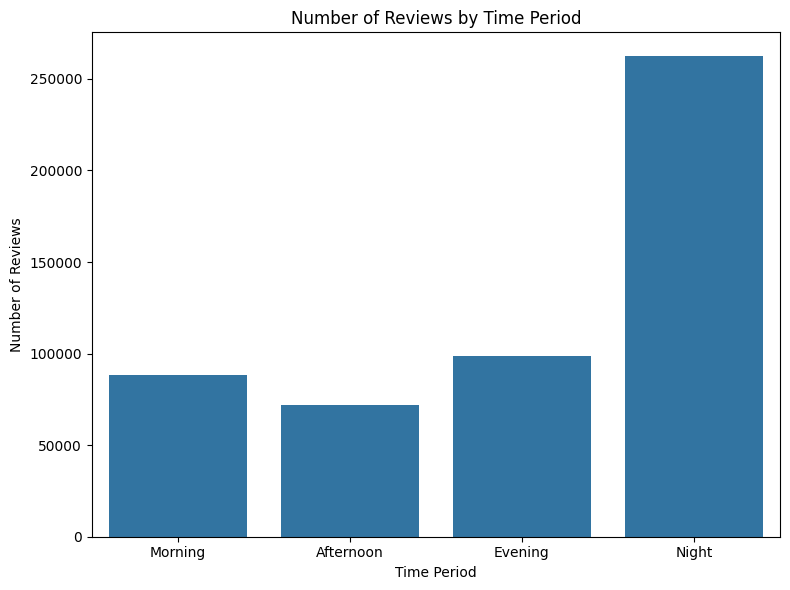

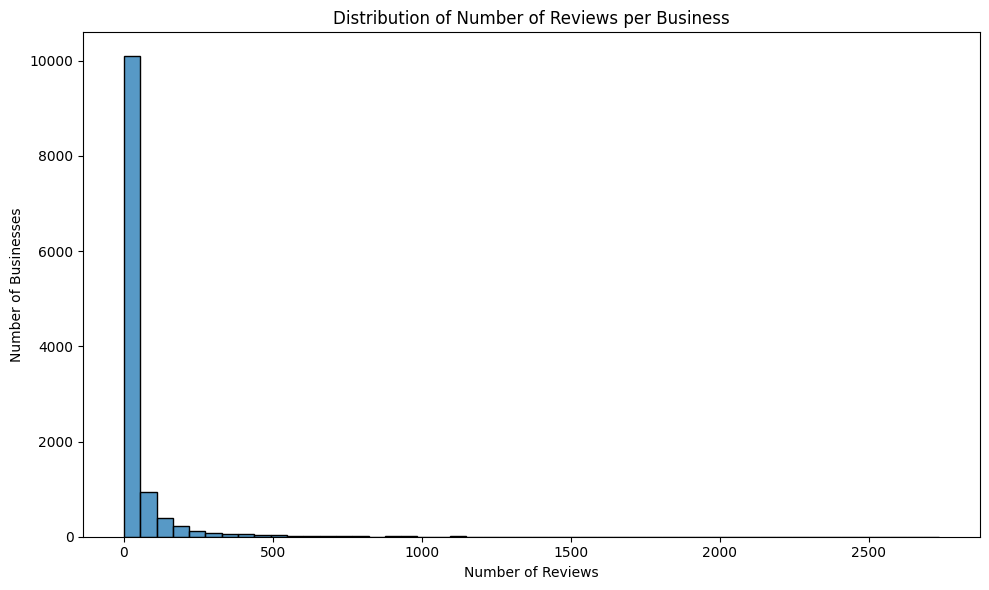

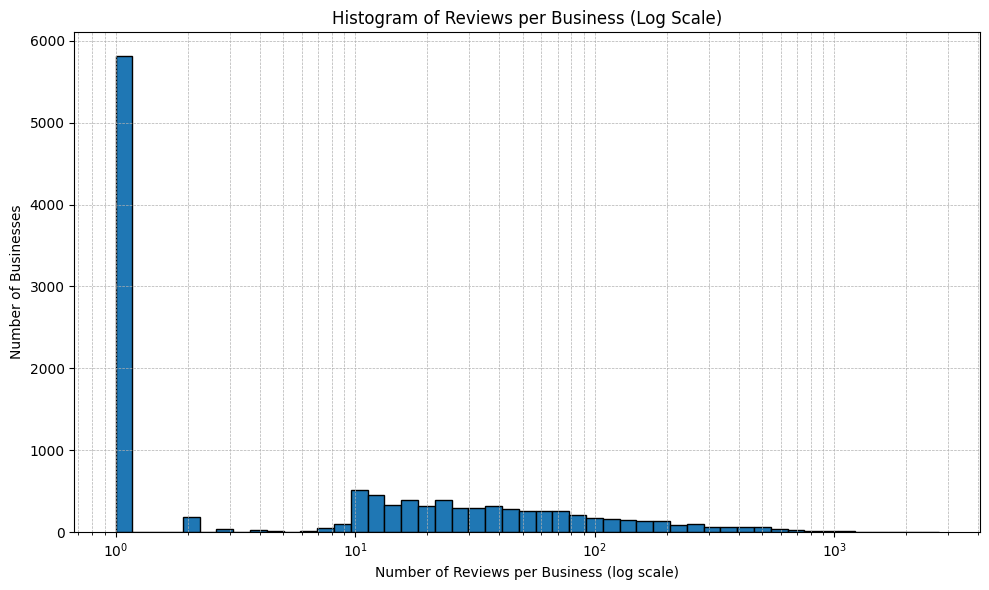

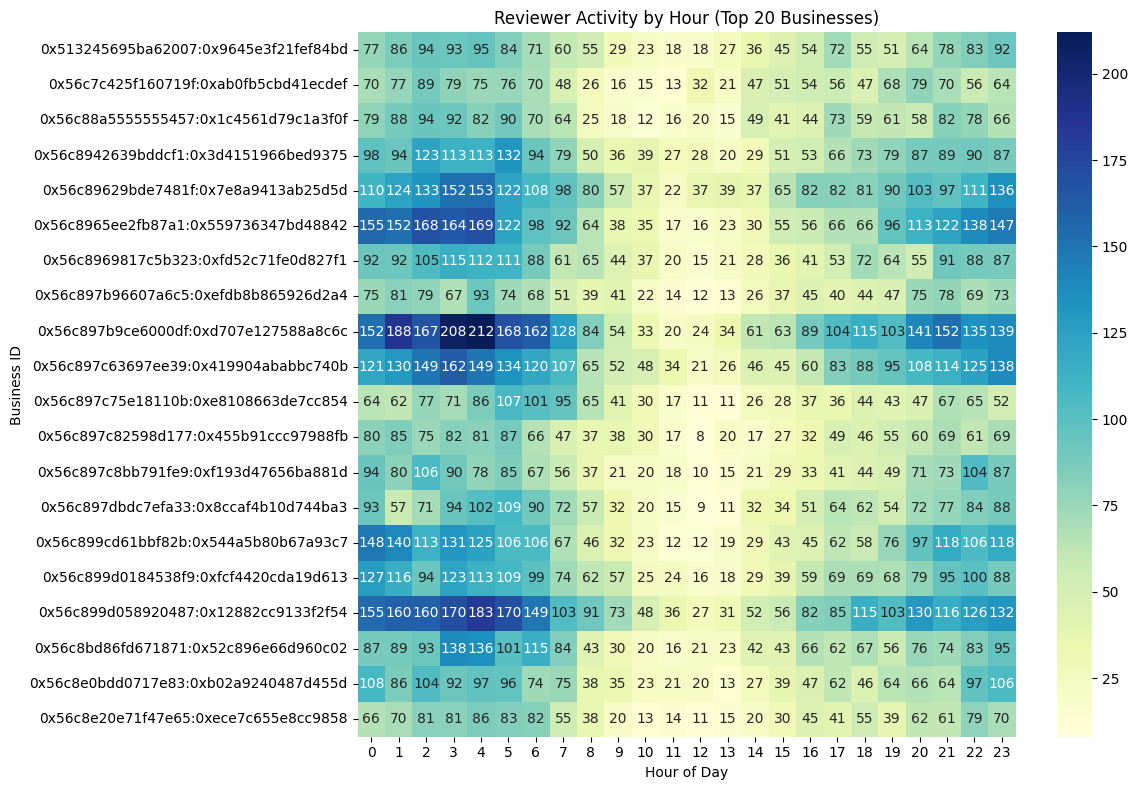

In [11]:
""" 1.2.3
Using matplotlib or seaborn to draw some (two or more if possible) visualizations on the
relationship between gmap_id and reivew_time. You could explore for example, what is the
time people usually review? How many business is reviewed in the morning time etc. Please
also discuss the insights you are finding with your visualizations in the markdown cell. Please
also include your findings and visualizations in the report.


Plots:
1. Distribution of Review Times across the day
   - What time do people usually leave reviews?
2. Number of reviews by time period Morning Hours (6am–12pm), Afternoon Hours (12pm–6pm), Evening Hours (6pm–9pm), Night (9pm-6am)
   - How active are reviewers during different parts of the day?
3. Histogram of Number of Reviews per business:
4. Reviewer Activity by Hour heatmap (Top 20 Businesses)
   - Do most reviewed businesses recieve revews at a particular time?
   - Are there consistent patterns in their activity?
"""
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define time periods
def get_time_period(hour):
  """
  """
  if 6 <= hour < 12:
    return "Morning"
  elif 12 <= hour < 18:
    return "Afternoon"
  elif 18 <= hour < 22:
    return "Evening"
  else:
    return "Night"

# Create timeperiod from review_time
df["time_period"] = df["review_time"].apply(get_time_period)

# Get a count of reviews per gmap_id
review_counts = df["gmap_id"].value_counts()

# Plot 1: Distribution of review times across the day
# What time do people usually leave reviews?
plt.figure(figsize=(10, 6))
sns.histplot(df["review_time"], bins=24, kde=False)
plt.title("Distribution of Review Times Across the Day")
plt.xlabel("Hour of Day")
plt.ylabel('Number of Reviews')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 1b: Distribution of review times for businesses with only one review
# Filter to businesses with exactly one review
single_reviews = review_counts[review_counts == 1].index
df_single = df[df["gmap_id"].isin(single_reviews)]

# Plot histogram of review hours
plt.figure(figsize=(10, 6))
plt.hist(df_single["review_time"], bins=24, range=(0, 24), edgecolor="black")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Times for Businesses with Only One Review")
plt.xticks(range(0, 24))
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Plot 2: Number of Reviews by Time Period
plt.figure(figsize=(8, 6))
sns.countplot(x='time_period', data=df, order=['Morning', 'Afternoon', 'Evening', 'Night'])
plt.title('Number of Reviews by Time Period')
plt.xlabel('Time Period')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

# Plot 3: Histogram of number of reviews per business
plt.figure(figsize=(10, 6))
sns.histplot(review_counts, bins=50, kde=False)
plt.title("Distribution of Number of Reviews per Business")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Businesses")
plt.tight_layout()
plt.show()

# Create histogram with log scale on x-axis
plt.figure(figsize=(10, 6))
plt.hist(review_counts, bins=np.logspace(np.log10(1), np.log10(max(review_counts)), 50), edgecolor="black")
plt.xscale("log")
plt.xlabel("Number of Reviews per Business (log scale)")
plt.ylabel("Number of Businesses")
plt.title("Histogram of Reviews per Business (Log Scale)")
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# Create a boxplot
#plt.figure(figsize=(10, 6))
#plt.boxplot(review_counts, vert=False)
#plt.title("Distribution of Number of Reviews per Business")
#plt.xlabel("Number of Reviews")
#plt.grid(True)
#plt.tight_layout()
#plt.show()

# Create a violin plot
#plt.figure(figsize=(10, 6))
#sns.violinplot(data=review_counts, inner="box", orient="h", color="skyblue")
#plt.title("Distribution of Number of Reviews per Business")
#plt.xlabel("Number of Reviews")
#plt.tight_layout()
#plt.show()


# Plot 4: Heatmap of reviewer activity by hour (top 20 businesses)
top_reviewers = review_counts.head(20).index
top_df = df[df["gmap_id"].isin(top_reviewers)]

# Create a pivot table: rows = businesses, columns = hours, values = number of reviews
activity_matrix = top_df.pivot_table(index="gmap_id", columns="review_time", aggfunc="size", fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(activity_matrix, cmap="YlGnBu", annot=True, fmt="d")
plt.title("Reviewer Activity by Hour (Top 20 Businesses)")
plt.xlabel("Hour of Day")
plt.ylabel("Business ID")
plt.tight_layout()
plt.show()

## Answer 1.3

Workday with the highest average number of reviews: Sunday


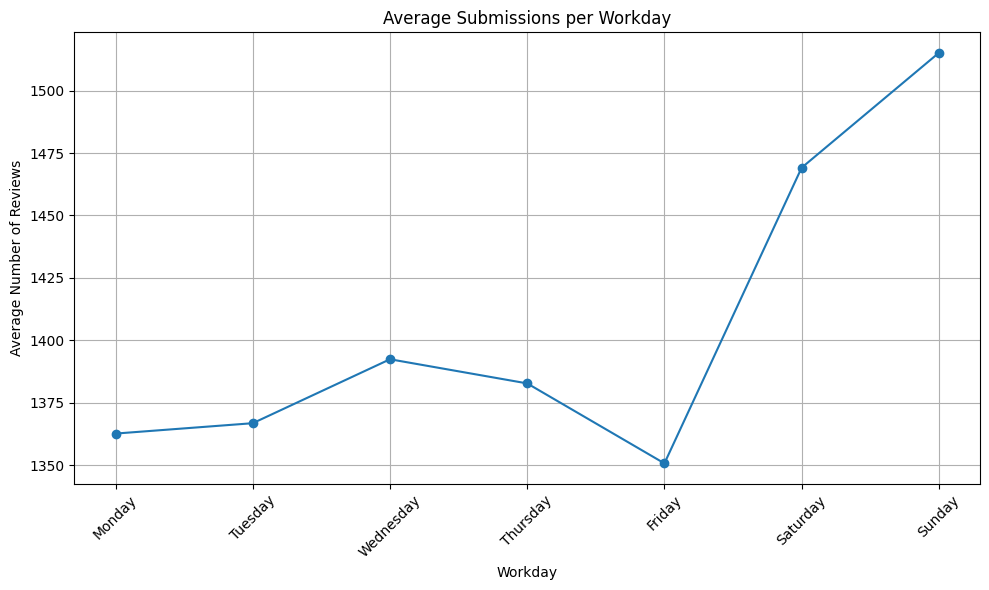

In [17]:
""" 1.3.1 Determine which workday (day of the week), generates the most reviews (plotting the results
in a line chart with workday on averaged submissions).
"""
import matplotlib.pyplot as plt
# Use the time column to get a DateTime object
# extract the day of the week from the DateTime object
df["workday"] = df["date_time"].dt.strftime("%A")

# Also need the week number to average the submissions
df["week"] = df["date_time"].dt.isocalendar().week

# Calculate the number of reviews for each day in each week
weekly_counts = df.groupby(["week", "workday"]).size().reset_index(name="review_counts")

# Calculate average reviews per weekday across all weeks
# Reindex for plotting
average_reviews = weekly_counts.groupby("workday")['review_counts'].mean().reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])

# Identify the weekday with the highest average reviews
busiest_workday = average_reviews.idxmax()
print(f"Workday with the highest average number of reviews: {busiest_workday}")

# Plotting the results in a line chart
plt.figure(figsize=(10, 6))
plt.plot(average_reviews.index, average_reviews.values, marker='o', linestyle='-')
plt.title("Average Submissions per Workday")
plt.xlabel("Workday")
plt.ylabel("Average Number of Reviews")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The number of business that recived an average rating of 5.0 on Sunday's is 1120.


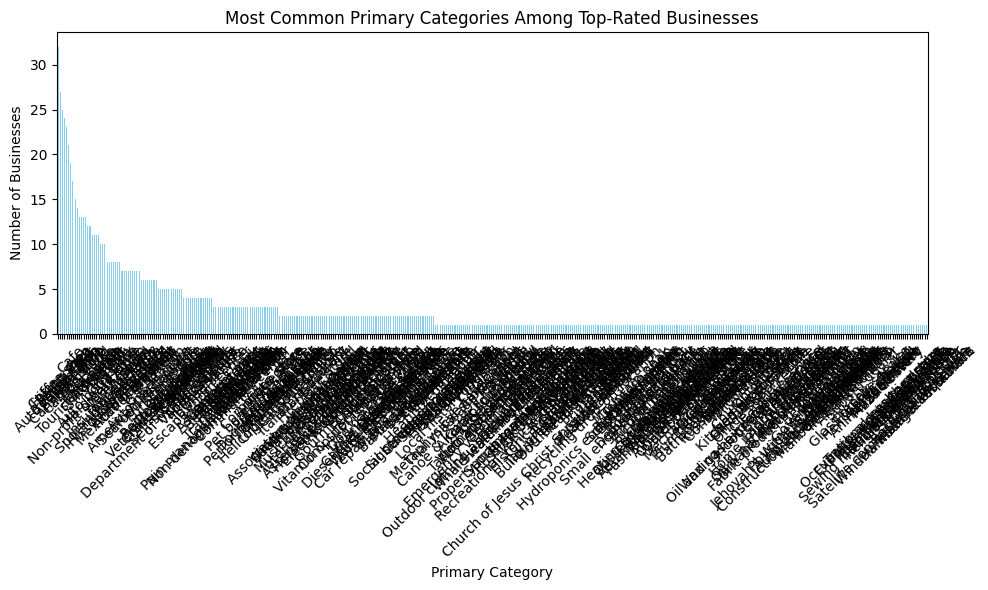

In [18]:
""" 1.3.2 Identify the names of business (column name from data meta-business) that has the highest
averaged ratings on ‘that workday’ (you need to find out from 1.3.1), and find out which
category those businesses are from?
"""
from collections import Counter
import ast

# Load meta-review-business data
meta_file_path = "./data/meta-review-business.csv"
meta_business_df = pd.read_csv(meta_file_path)
meta_business_df = meta_business_df.rename(columns={"name": "business_name", "category": "business_category"})

# Select only the relevant columns from meta-review-business
meta_subset_df = meta_business_df[["gmap_id", "business_name", "business_category"]]

# Filter reviews for the busiest weekday
reviews_on_busiest_day = df[df["workday"] == busiest_workday]

# Join with meta-business to get business names and categories
merged_df = pd.merge(reviews_on_busiest_day, meta_subset_df, on="gmap_id", how="left")

# Need to ensure rating values are floats
merged_df["rating"] = pd.to_numeric(merged_df["rating"], errors='coerce')

# Calculate average rating per business
avg_ratings = merged_df.groupby("business_name")["rating"].mean()

# Find business(es) with highest average rating
max_avg_rating = avg_ratings.max()
top_businesses = avg_ratings[avg_ratings == max_avg_rating].index.tolist()

print(f"The number of business that recived an average rating of {max_avg_rating} on {busiest_workday}'s is {len(top_businesses)}.")

# Filter merged_df to include only top-rated businesses
filtered_df = merged_df[merged_df["business_name"].isin(top_businesses)]

# Select business name and category
top_bus_cat = filtered_df[["business_name", "business_category"]]

# Drop duplicates
top_bus_cat = top_bus_cat.drop_duplicates("business_name").reset_index(drop=True)

# Categories are stories as strings, convert them to a list
top_bus_cat["business_category"] = top_bus_cat["business_category"].apply(ast.literal_eval)

# Extract only the first category from each list
top_bus_cat["primary_category"] = top_bus_cat["business_category"].apply(lambda x: x[0] if isinstance(x, list) and x else None)

# Count the most common primary categories
category_counts = top_bus_cat["primary_category"].value_counts()

# Plot the results
plt.figure(figsize=(10, 6))
category_counts.plot(kind="bar", color="skyblue")
plt.title("Most Common Primary Categories Among Top-Rated Businesses")
plt.xlabel("Primary Category")
plt.ylabel("Number of Businesses")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### WIP: NEED TO FIGURE OUT HOW TO VISUALISE THE DATA BETTER. MAYBE A WORD CLOUD OR TREEMAP?

## Answer 1.4

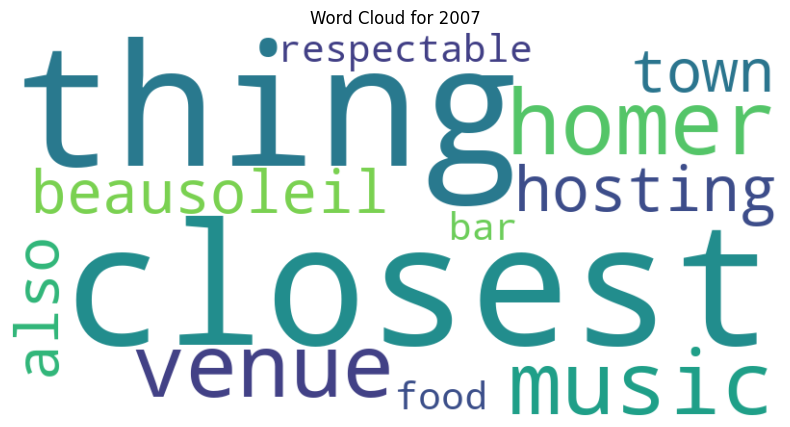

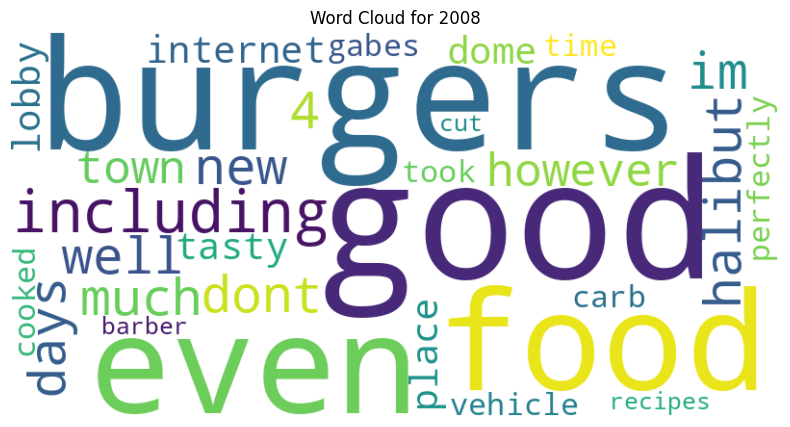

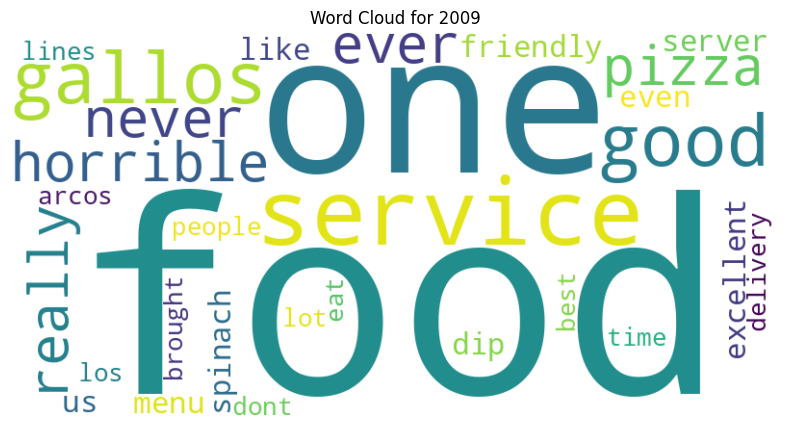

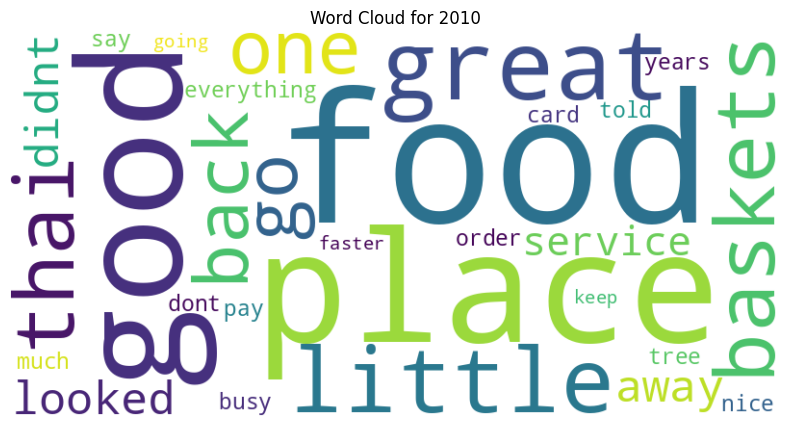

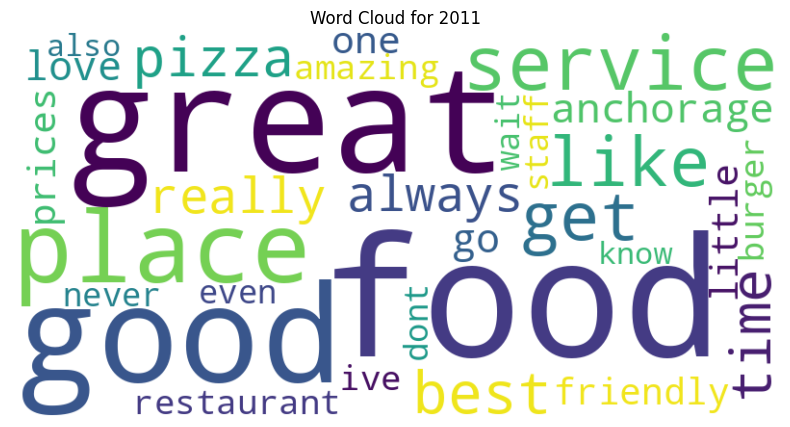

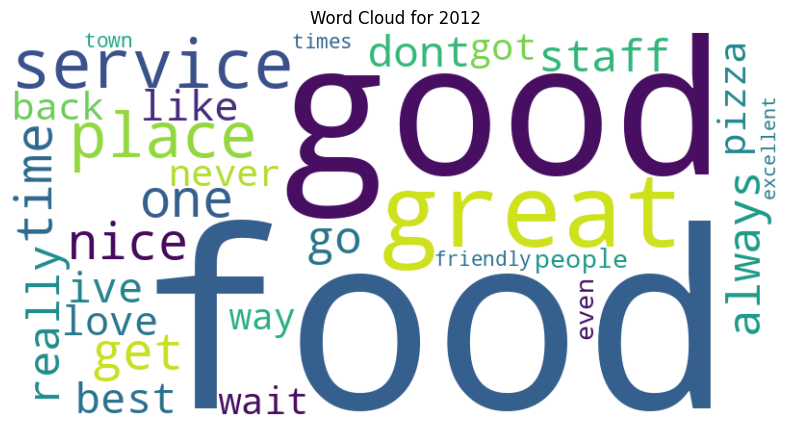

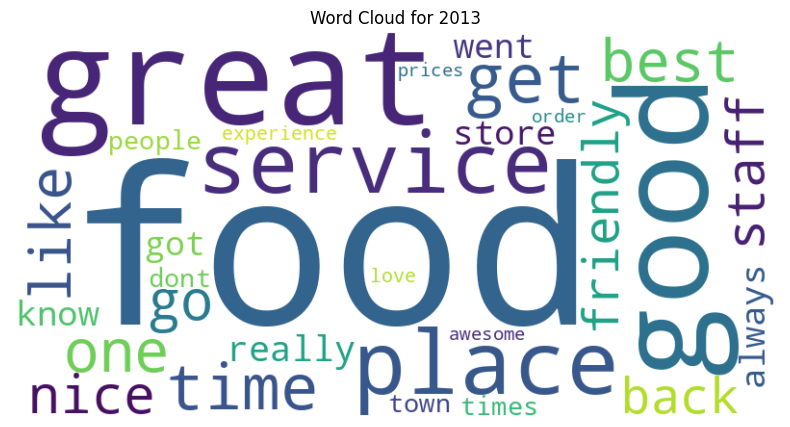

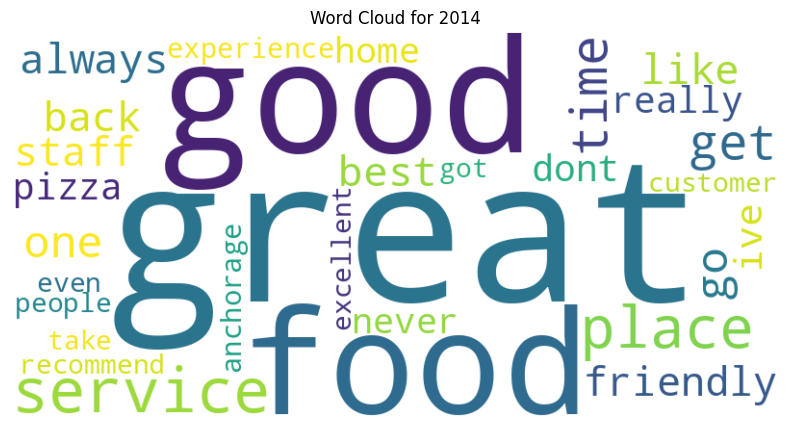

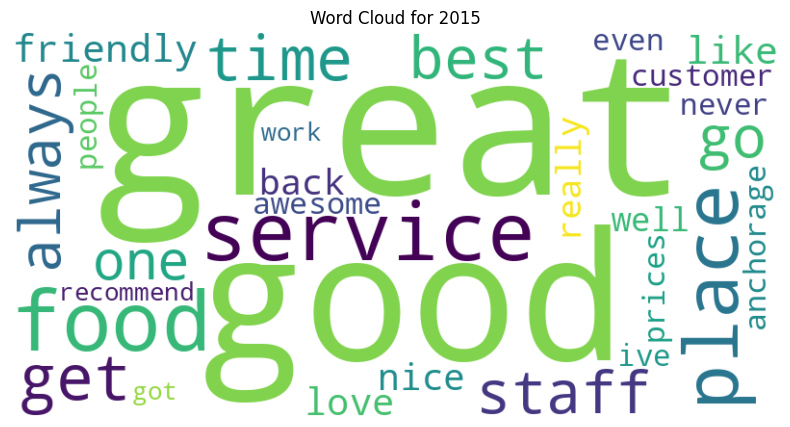

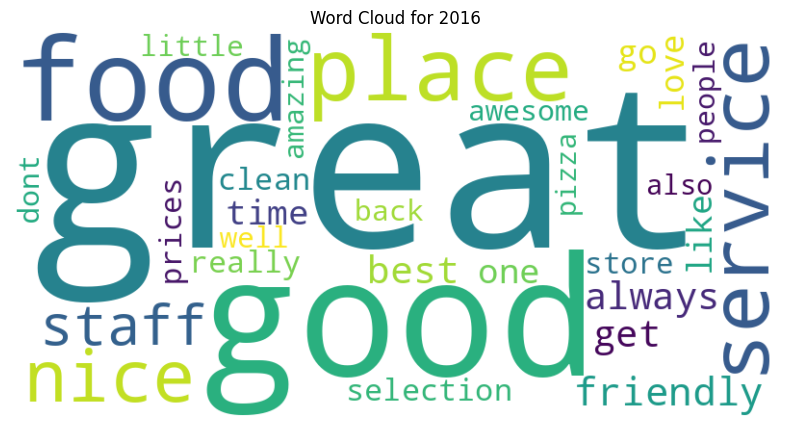

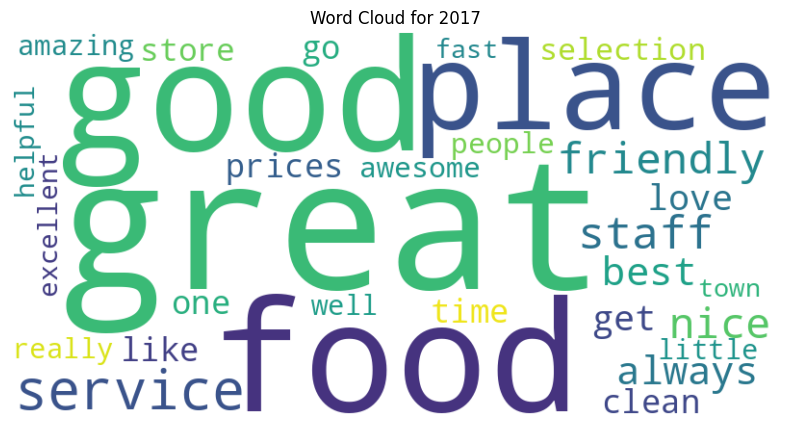

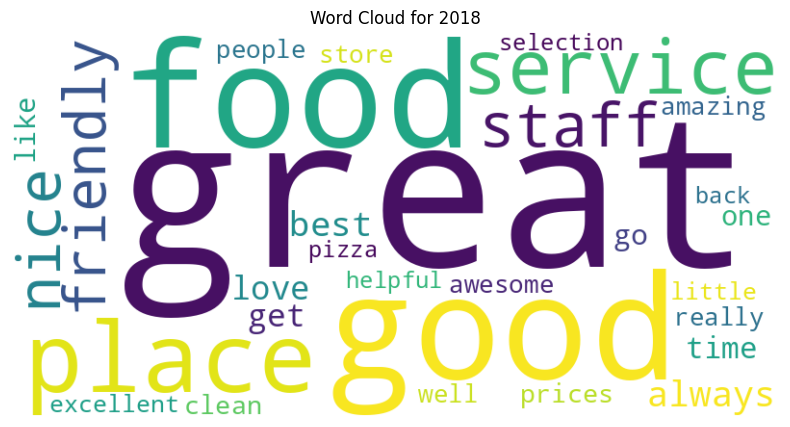

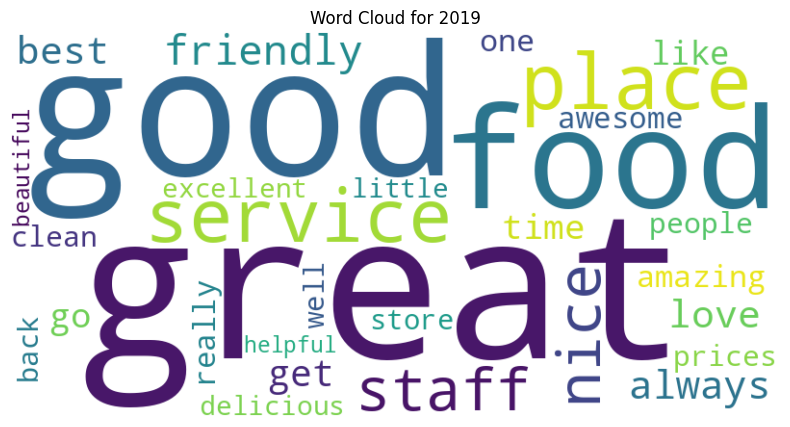

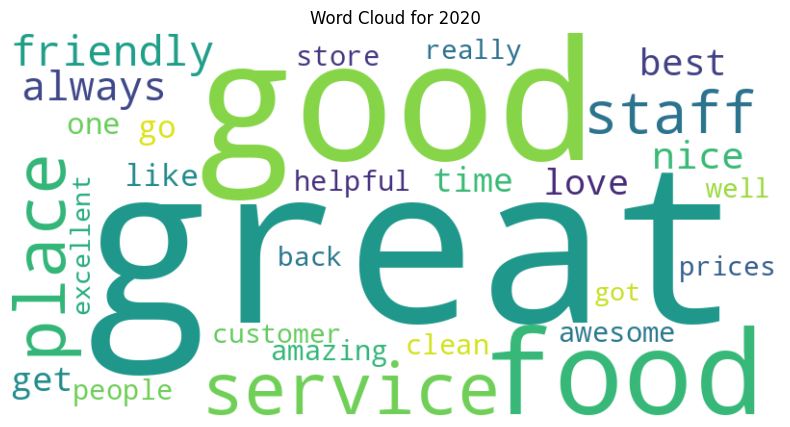

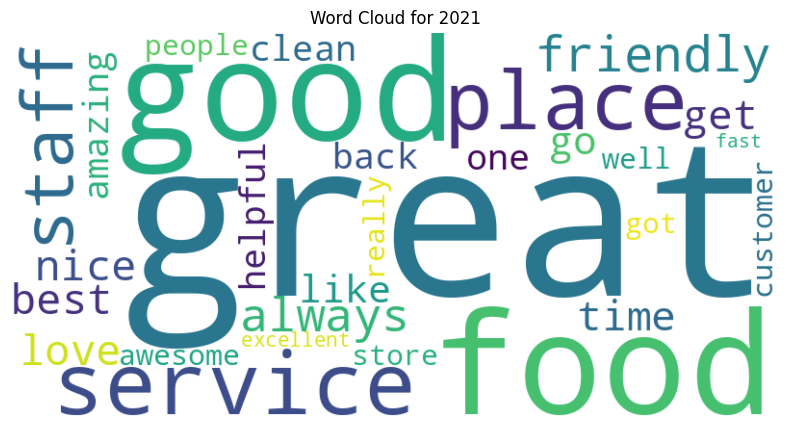

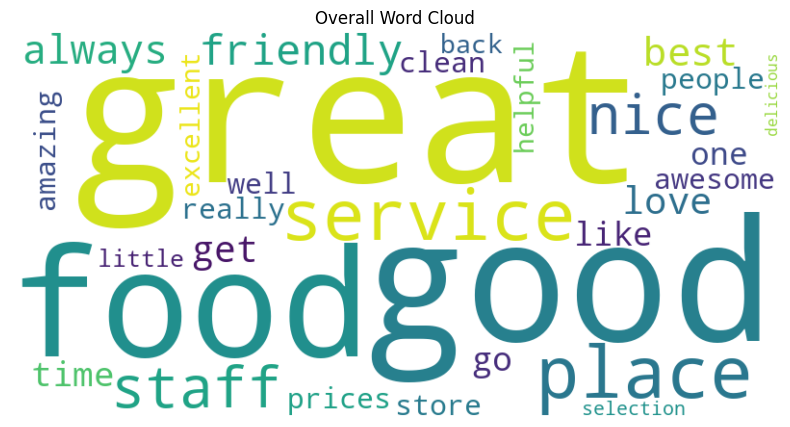

In [14]:
""" 1.4 Find top 30 common words in reviews. Generate word clouds by review year.

Decided to use pySpark for this question as we are ptentially working with large
data.
"""

from pyspark.sql.functions import explode, split, lower, col, regexp_replace, year, to_date, collect_list, flatten
from pyspark.ml.feature import StopWordsRemover
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create new dataframe with only the columns we need.
words_sdf = sdf_cleaned.select("newTime", "text")

# Create "year" column from "newTime" to date and extract year.
words_sdf = words_sdf.withColumn("year",
                               year(to_date(col("newTime"), "yyyy-MM-dd")))

# For entries in the text column, remove punctuation and special charaters,
# keeping only letter, numbers and spaces.
# Convert the remaining text to lower case and split into a list of words at spaces
# Rename the column word_list
words_sdf = words_sdf.withColumn("words_list",
        split(
            lower(
                regexp_replace(col("text"), "[^a-zA-Z0-9\\s]", "")
            ), "\\s+"
        )
)

# Remove stop words (“the”, “is”, “and”) words using StopWordsRemover
# Get default stop words
default_stopwords = StopWordsRemover().getStopWords()

# In 1.1.1 we replaced NULL entries with "no review".
custom_stopwords = default_stopwords + ["no", "review"]

# Input column is words_list output column filtered
remover = StopWordsRemover(inputCol="words_list",
                           outputCol="filtered_words").setStopWords(custom_stopwords)

# Do the removal
words_sdf = remover.transform(words_sdf)

# Group by year and collect all words into one list for each year flattening the list for each year
grouped_yrs = words_sdf.groupBy("year").agg(flatten(collect_list("filtered_words")).alias("all_words"))

# Convert to Pandas for word cloud generation
grouped_yrs_pd = grouped_yrs.toPandas()

# Sort by year in ascending order
grouped_yrs_pd_sorted = grouped_yrs_pd.sort_values(by="year")

# Count words and generate word clouds
year_word_counts = {}
for _, row in grouped_yrs_pd_sorted.iterrows():
    year = row["year"]
    words = row["all_words"]
    word_freq = Counter(words).most_common(30)
    year_word_counts[year] = dict(word_freq)

    # Generate word cloud for each year
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(year_word_counts[year])
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {int(year)}")
    plt.show()

# Overall word cloud
overall_counter = Counter()
for freq_dict in year_word_counts.values():
    overall_counter.update(freq_dict)

overall_top_30 = dict(overall_counter.most_common(30))

# Plot
wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(overall_top_30)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Overall Word Cloud")
plt.show()


## Answer 1.5

# **Answer 1.6**

**Q1.6.1 Strategy (≤120 words):**  
We decided to use Collaborative Filtering with the ALS (Alternating Least Squares) algorithm in Spark to build the recommendation system. The model learns latent factors from user–business interactions (ratings) and predicts unseen preferences. ALS is suitable for large-scale review data because it is efficient and scalable. The strategy is to train on `(user_id, gmap_id, rating)` and then recommend top-N businesses for each user. This approach captures hidden patterns across the community, providing personalized suggestions. Alternative strategies include Content-based Filtering using business categories or hybrid models combining both methods. Our chosen ALS method is optimal here due to Spark’s distributed processing and the rich rating data available, though it still faces the cold-start limitation.


In [21]:
from pyspark.ml.recommendation import ALS
from pyspark.sql.functions import col
import pandas as pd
from pyspark.ml.feature import StringIndexer

# Load meta-review-business data
meta_file_path = "./data/meta-review-business.csv"
meta_business_df = pd.read_csv(meta_file_path)
meta_business_df = meta_business_df.rename(columns={"name": "business_name", "category": "business_category"})

# Select only the relevant columns from meta-review-business
meta_subset_df = meta_business_df[["gmap_id", "business_name", "business_category"]]

# Convert meta_subset_df to Spark DataFrame for joining
meta_subset_sdf = spark.createDataFrame(meta_subset_df)

# Join sdf_cleaned with meta_subset_sdf
joined = sdf_cleaned.join(meta_subset_sdf, on="gmap_id", how="inner")

# Prepare the dataset: cast userid, gmap_id, and rating into int/float
# Assuming 'user_id' is the user identifier in sdf_cleaned

# Indexing user_id and gmap_id
indexer_user = StringIndexer(inputCol="user_id", outputCol="user_index")
indexer_item = StringIndexer(inputCol="gmap_id", outputCol="item_index")

# Fit and transform the data
indexed_df = indexer_user.fit(joined).transform(joined)
indexed_df = indexer_item.fit(indexed_df).transform(indexed_df)

# Create lookup table: item_index -> gmap_id, business_name
item_lookup = indexed_df.select("item_index", "gmap_id", "business_name").dropna().distinct()

# Select the necessary columns for ALS model
ratings = indexed_df.select(
    col("user_index").cast("int").alias("user"),
    col("item_index").cast("int").alias("item"),
    col("rating").cast("float").alias("rating")
).dropna()

# Train ALS model
# Use the correct column names after aliasing
als = ALS(
    userCol="user", itemCol="item", ratingCol="rating",
    coldStartStrategy="drop", nonnegative=True
)
model = als.fit(ratings)

# Generate top-5 business recommendations for each user
user_recs = model.recommendForAllUsers(5)
user_recs.show(5, truncate=False)

+----+----------------------------------------------------------------------------------------------+
|user|recommendations                                                                               |
+----+----------------------------------------------------------------------------------------------+
|1   |[{5035, 4.2009854}, {3135, 4.193831}, {5497, 4.186749}, {4378, 4.1846147}, {4534, 4.1693864}] |
|3   |[{4721, 5.869679}, {4378, 5.8684855}, {5919, 5.8440037}, {4224, 5.7559314}, {4171, 5.7332525}]|
|5   |[{5919, 5.34004}, {4378, 5.3295107}, {4530, 5.2989173}, {5098, 5.2757134}, {5334, 5.250723}]  |
|6   |[{4374, 5.3135104}, {2242, 5.193006}, {4378, 5.140092}, {4883, 5.138318}, {4010, 5.0970864}]  |
|9   |[{4853, 5.0630064}, {5010, 5.0500855}, {5620, 5.041989}, {5873, 5.0388594}, {4683, 5.0214095}]|
+----+----------------------------------------------------------------------------------------------+
only showing top 5 rows



In [25]:
from pyspark.sql.functions import col, explode

# Build lookup: item_index (cast to int) -> gmap_id, business_name
item_lookup = (indexed_df
               .select(col("item_index").cast("int").alias("item"),
                       "gmap_id", "business_name")
               .dropna()
               .distinct())

# Flatten recommendations
user_recs_flat = (user_recs
                  .selectExpr("user", "explode(recommendations) as rec")
                  .select("user",
                          col("rec.item").alias("item"),
                          col("rec.rating").alias("pred_rating")))

# Join to get names
user_recs_named = (user_recs_flat
                   .join(item_lookup, on="item", how="left")
                   .orderBy("user", col("pred_rating").desc()))

user_recs_named.show(20, truncate=False)


+----+----+-----------+-------------------------------------+---------------------------------------------------------+
|item|user|pred_rating|gmap_id                              |business_name                                            |
+----+----+-----------+-------------------------------------+---------------------------------------------------------+
|5339|0   |5.3324513  |0x56c91a37b305fb3d:0xd44909bc1934023c|Hilltop Premium Green                                    |
|5707|0   |5.258778   |0x56c66163f434426b:0x7467430f74f3752b|Magnum Motors                                            |
|6008|0   |5.253828   |0x56c12d9686f6b565:0x88c198615c170e13|Homer Saw & Cycle                                        |
|4865|0   |5.2449236  |0x56c898134eb27117:0x2bb6aa05e8377fdd|Ravens Nest Spa                                          |
|5919|0   |5.2030993  |0x56c89776a36b2789:0xbf7e239b950da784|Borman Auto                                              |
|5035|1   |4.2009854  |0x56c89785c5e6dd8

**Insights (Q1.6.2):**  
After training the ALS model, the recommendation output was originally in numeric indices (user_index, item_index). To make the results interpretable, we built a lookup table linking `item_index` back to `gmap_id` and `business_name`. Exploding the recommendations for each user allowed us to list the top-N suggested businesses together with their predicted scores. This approach makes the recommendations meaningful (e.g., “Sushi Train Melbourne, predicted rating 5.87”) instead of just showing numeric IDs. The method is optimal for reporting and presentation because it preserves the ALS accuracy while providing human-readable results. An alternative would be to export results and perform the mapping in Pandas, but joining directly in Spark is more efficient.


# Stop Spark